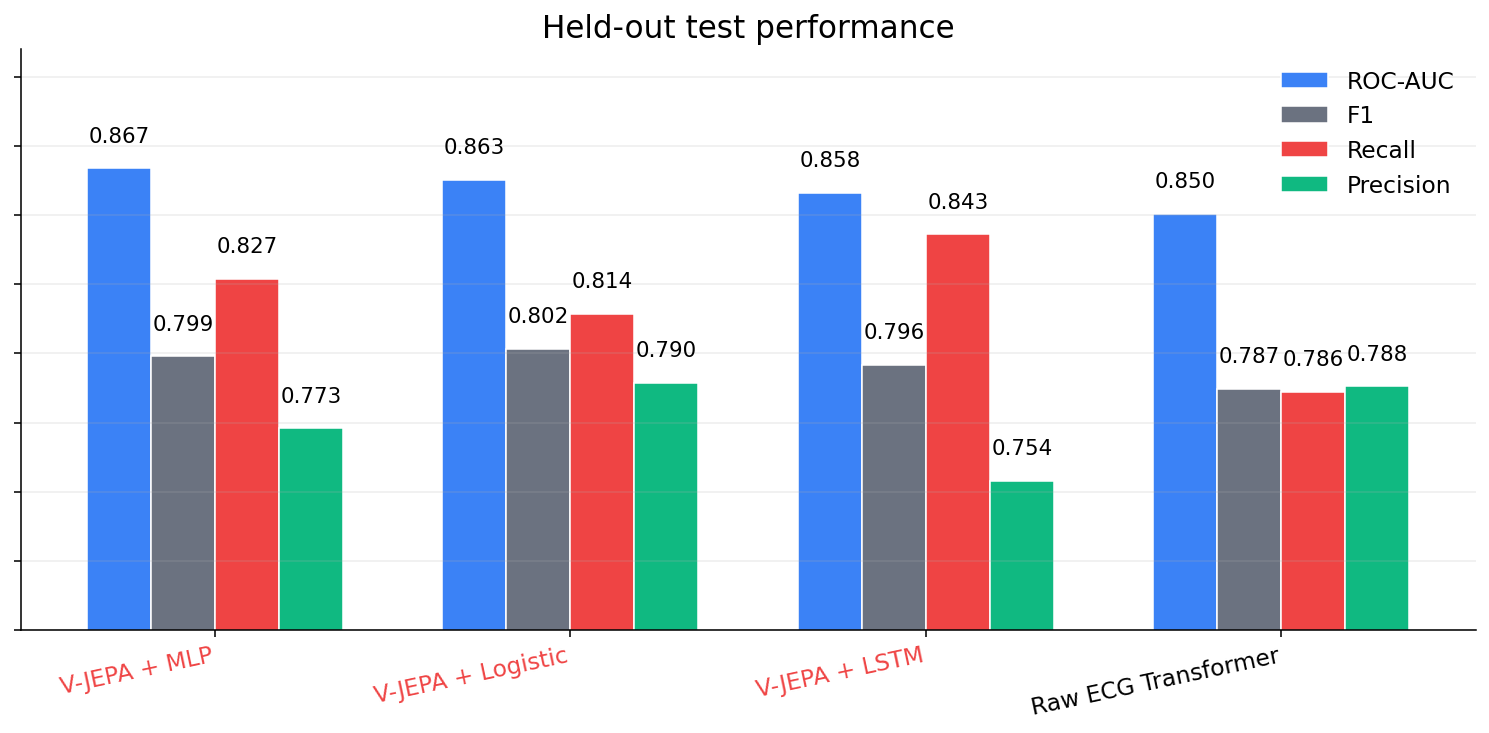

In [ ]:
emb_lstm = { 
    'model': 'emb_lstm',
    'test_roc_auc': 0.858,
    'test_f1': 0.796,
    'test_recall': 0.843,
    'test_precision': 0.754
            }

emb_mlp = { 
    'model': 'emb_mlp',
    'test_roc_auc': 0.867,
    'test_f1': 0.799,
    'test_recall': 0.827,
    'test_precision': 0.773
            }

ecg_transformer = {
    'model': 'ecg_transformer',
    'test_roc_auc': 0.8504,
    'test_f1': 0.7872,
    'test_recall': 0.7862,
    'test_precision': 0.7881
            }

emb_logistic = {
    'model': 'emb_logistic',
    'test_roc_auc': 0.8627800160080911,
    'test_f1': 0.8017481128327374,
    'test_recall': 0.814366424535916,
    'test_precision': 0.7895148669796557
}

import matplotlib.pyplot as plt
import numpy as np

models = [emb_mlp, emb_logistic, emb_lstm, ecg_transformer]
model_labels = {
    'emb_mlp': 'V-JEPA + MLP',
    'emb_logistic': 'V-JEPA + Logistic',
    'emb_lstm': 'V-JEPA + LSTM',
    'ecg_transformer': 'Raw ECG Transformer',
}
metric_labels = {
    'test_roc_auc': 'ROC-AUC',
    'test_f1': 'F1',
    'test_recall': 'Recall',
    'test_precision': 'Precision',
}
model_names = [model_labels[m['model']] for m in models]
metrics = list(metric_labels)
colors = {
    'test_roc_auc': '#3B82F6',
    'test_f1': '#6B7280',
    'test_recall': '#EF4444',
    'test_precision': '#10B981',
}

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 140,
})

fig, ax = plt.subplots(figsize=(10.8, 5.4))
fig.patch.set_facecolor('white')

x = np.arange(len(models))
bar_width = 0.18
for i, metric in enumerate(metrics):
    values = [m[metric] for m in models]
    offset = (i - (len(metrics) - 1) / 2) * bar_width
    bars = ax.bar(
        x + offset,
        values,
        width=bar_width,
        label=metric_labels[metric],
        color=colors[metric],
        edgecolor='white',
        linewidth=0.8,
    )
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.008,
            f'{value:.3f}',
            ha='center',
            va='bottom',
            fontsize=11,
        )

ax.set_title('Held-out test performance')
# ax.set_ylabel('Metric value')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=12, ha='right')
for tick, model in zip(ax.get_xticklabels(), models):
    if model['model'].startswith('emb_'):
        tick.set_color('#EF4444')
ax.set_ylim(0.70, 0.91)
ax.set_yticklabels([])
ax.grid(axis='y', alpha=0.22)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, ncol=1, loc='upper right')

fig.tight_layout()

plt.show()
